In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm
!pip install -q transformers datasets accelerate evaluate
!pip install -q torch
!pip install -q torch torchvision

In [ ]:
import pandas as pd
import numpy as np
import re
import random
import torch
import html
import unicodedata

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

In [ ]:
import torch

print("CUDA tersedia:", torch.cuda.is_available())
print("Nama GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
device=0 if torch.cuda.is_available() else -1

CUDA tersedia: True
Nama GPU: Tesla T4


In [ ]:
import pandas as pd

df = pd.read_csv("DatasetMBG (3).csv")

df = df[['full_text']].rename(
    columns={'full_text':'text'}
)

print(len(df))

3459


In [ ]:
df = df.dropna(subset=['text'])

df = df.drop_duplicates(
    subset=['text']
)

df = df.reset_index(drop=True)

print("Total data:", len(df))

Total data: 3335


In [ ]:
import re
import html
import unicodedata

normalization_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "tdk": "tidak",
    "tak": "tidak",
    "bgt": "banget",
    "bgtt": "banget",
    "yg": "yang",
    "dgn": "dengan",
    "dlm": "dalam",
    "krn": "karena",
    "karna": "karena",
    "utk": "untuk",
    "dr": "dari",
    "sm": "sama",
    "aja": "saja",
    "tp": "tapi",
    "tpi": "tapi",
    "jd": "jadi",
    "sdh": "sudah",
    "udah": "sudah",
    "blm": "belum",
    "pdhl": "padahal",
    "org": "orang"
}

def normalize_slang(text):
    words = text.split()
    return " ".join(
        normalization_dict.get(word, word)
        for word in words
    )

def reduce_repeated_char(text):
    return re.sub(
        r'(.)\1{2,}',
        r'\1\1',
        text
    )

def minimal_cleaning(text):

    text = str(text)

    text = html.unescape(text)

    text = unicodedata.normalize(
        "NFKC",
        text
    )

    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    text = re.sub(
        r'@\w+',
        ' ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

def text_preprocessing(text):

    text = str(text)

    text = html.unescape(text)

    text = unicodedata.normalize(
        "NFKC",
        text
    )

    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    text = re.sub(
        r'@\w+',
        ' ',
        text
    )

    text = re.sub(
        r'#',
        '',
        text
    )

    text = text.lower()

    text = reduce_repeated_char(text)

    text = re.sub(
        r'[^a-zA-Z0-9\s]',
        ' ',
        text
    )

    text = normalize_slang(text)

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

In [ ]:
df['text_light'] = df['text'].apply(
    minimal_cleaning
)

df['text_clean'] = df['text_light'].apply(
    text_preprocessing
)

df = df[
    df['text_clean'].str.strip() != ""
]

df = df.reset_index(drop=True)

print(
    "Data setelah preprocessing:",
    len(df)
)

Data setelah preprocessing: 3333


In [ ]:
df = df.drop_duplicates(
    subset='text_clean'
).reset_index(drop=True)

print(
    "Data unik:",
    len(df)
)

Data unik: 3002


In [ ]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier",
    device=0 if torch.cuda.is_available() else -1
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
texts = df['text_light'].tolist()

results = sentiment_model(
    texts,
    batch_size=32,
    truncation=True,
    max_length=512
)

df['pseudo_label_raw'] = [
    r['label']
    for r in results
]

df['pseudo_score'] = [
    r['score']
    for r in results
]

In [ ]:
def map_sentiment(label):

    label = str(label).lower()

    if 'pos' in label:
        return 'positif'

    elif 'neg' in label:
        return 'negatif'

    else:
        return 'netral'


df['sentiment'] = (
    df['pseudo_label_raw']
    .apply(map_sentiment)
)

In [ ]:
df.to_csv(
    "dataset_pseudo_labeled.csv",
    index=False
)

In [ ]:
from sklearn.model_selection import train_test_split

validation_df, _ = train_test_split(
    df,
    test_size=(len(df)-350)/len(df),
    stratify=df['sentiment'],
    random_state=42
)

validation_df = (
    validation_df
    .reset_index(drop=True)
)

print(len(validation_df))

350


In [ ]:
validation_df[
    [
        'text',
        'text_light',
        'text_clean',
        'sentiment'
    ]
].to_excel(
    "manual_validation_sample.xlsx",
    index=False
)

In [ ]:
manual_df = pd.read_excel(
    "final_manual_validation_fixed.xlsx"
)

print(len(manual_df))

350


In [ ]:
agreement = (
    manual_df['sentiment']
    ==
    manual_df['manual']
).mean()

print(
    f"Agreement: {agreement:.2%}"
)

Agreement: 76.00%


In [ ]:
final_df = df.merge(
    manual_df[
        ['text_clean','manual']
    ],
    on='text_clean',
    how='left'
)

In [ ]:
final_df['final_label'] = (
    final_df['manual']
    .fillna(
        final_df['sentiment']
    )
)

In [ ]:
print(
    "Total data:",
    len(final_df)
)

print(
    "Data manual:",
    final_df['manual']
    .notna()
    .sum()
)

Total data: 3020
Data manual: 350


/tmp/ipykernel_1807/4182777562.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


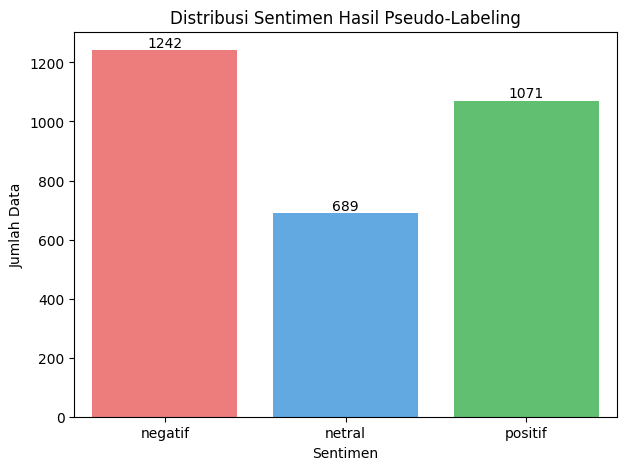

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

order = ['negatif','netral','positif']

colors = [
    '#ff6b6b',  # merah
    '#4dabf7',  # biru
    '#51cf66'   # hijau
]

ax = sns.countplot(
    data=df,
    x='sentiment',
    order=order,
    palette=colors
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Sentimen Hasil Pseudo-Labeling')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')

plt.show()

/tmp/ipykernel_1807/3293324794.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


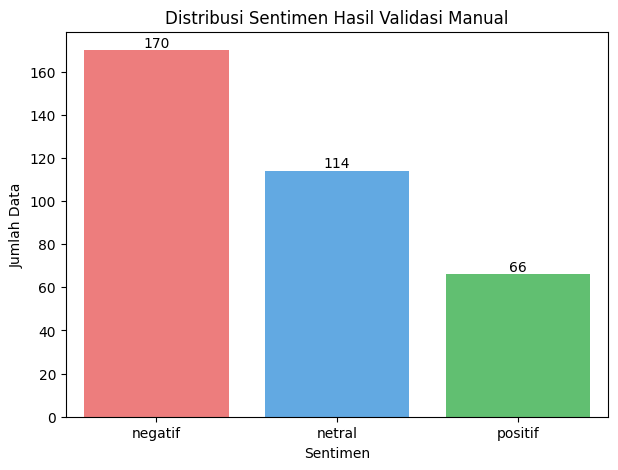

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=manual_df,
    x='manual',
    order=order,
    palette=colors
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Sentimen Hasil Validasi Manual')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')

plt.show()

In [ ]:
changed = (
    manual_df['sentiment']
    !=
    manual_df['manual']
).sum()

unchanged = (
    manual_df['sentiment']
    ==
    manual_df['manual']
).sum()

print("Tetap :", unchanged)
print("Berubah :", changed)

Tetap : 266
Berubah : 84


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

final_df['label'] = (
    le.fit_transform(
        final_df['final_label']
    )
)

print(le.classes_)

['negatif' 'netral' 'positif']


In [ ]:
final_df.to_csv(
    "final_dataset_sentiment.csv",
    index=False
)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    final_df,
    test_size=0.2,
    random_state=42,
    stratify=final_df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print("Train :", len(train_df))
print("Val   :", len(val_df))
print("Test  :", len(test_df))

Train : 2416
Val   : 302
Test  : 302


In [ ]:
X_train = train_df['text_clean']
X_val   = val_df['text_clean']
X_test  = test_df['text_clean']

y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

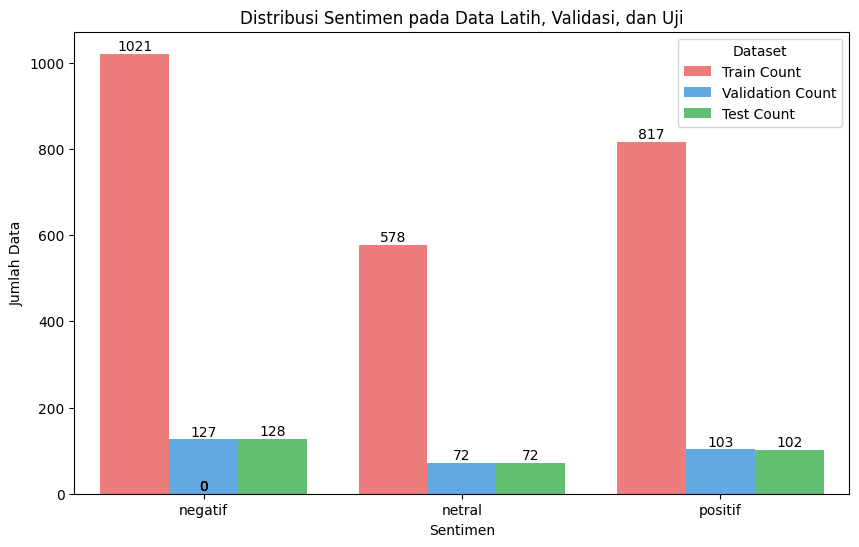

In [ ]:
train_counts = train_df['final_label'].value_counts().reset_index()
train_counts.columns = ['Sentiment', 'Train Count']

val_counts = val_df['final_label'].value_counts().reset_index()
val_counts.columns = ['Sentiment', 'Validation Count']

test_counts = test_df['final_label'].value_counts().reset_index()
test_counts.columns = ['Sentiment', 'Test Count']


distribution_df = train_counts.merge(val_counts, on='Sentiment', how='outer').merge(test_counts, on='Sentiment', how='outer')
distribution_df = distribution_df.set_index('Sentiment').loc[order].reset_index().fillna(0)

distribution_df_melted = distribution_df.melt(id_vars=['Sentiment'], var_name='Dataset', value_name='Count')

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=distribution_df_melted,
    x='Sentiment',
    y='Count',
    hue='Dataset',
    palette=colors,
    order=order
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Sentimen pada Data Latih, Validasi, dan Uji')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')
plt.legend(title='Dataset')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

In [ ]:
X = final_df['text_clean']
y = final_df['label']

Split TF

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[['text_clean','label']]
)

val_dataset = Dataset.from_pandas(
    val_df[['text_clean','label']]
)

test_dataset = Dataset.from_pandas(
    test_df[['text_clean','label']]
)

# ML

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        svm_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

     negatif       0.76      0.80      0.78       128
      netral       0.74      0.60      0.66        72
     positif       0.65      0.70      0.67       102

    accuracy                           0.72       302
   macro avg       0.72      0.70      0.70       302
weighted avg       0.72      0.72      0.71       302



In [ ]:
# Simpan hasil SVM

svm_result = {
    "y_true": y_test,
    "y_pred": svm_pred
}

print("Jumlah data test:", len(svm_result["y_true"]))
print("Jumlah prediksi :", len(svm_result["y_pred"]))

Jumlah data test: 302
Jumlah prediksi : 302


In [ ]:
svm_result

{'y_true': 1244    0
 1227    0
 1041    1
 807     0
 1559    0
        ..
 1477    2
 1564    2
 1849    2
 2550    0
 1187    0
 Name: label, Length: 302, dtype: int64,
 'y_pred': array([0, 0, 0, 2, 2, 2, 0, 1, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 1, 0, 2, 0,
        0, 0, 2, 1, 1, 0, 1, 0, 2, 2, 2, 2, 1, 2, 2, 0, 1, 1, 2, 2, 1, 0,
        2, 1, 2, 0, 0, 0, 2, 0, 0, 1, 0, 2, 2, 0, 0, 0, 2, 1, 2, 1, 2, 0,
        0, 0, 1, 0, 0, 0, 2, 0, 2, 2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 0, 0, 2,
        2, 2, 2, 1, 0, 2, 2, 0, 1, 0, 2, 0, 1, 2, 0, 0, 1, 1, 2, 2, 0, 2,
        1, 2, 2, 1, 0, 0, 2, 0, 1, 2, 0, 2, 1, 1, 2, 1, 2, 1, 0, 0, 0, 2,
        1, 0, 0, 2, 1, 2, 0, 0, 1, 2, 1, 0, 2, 0, 1, 0, 1, 0, 0, 0, 0, 0,
        1, 0, 2, 1, 1, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2, 2,
        0, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 2, 1, 1, 0, 0, 1, 2, 2, 0, 0, 0,
        0, 2, 0, 2, 2, 1, 0, 2, 2, 2, 1, 2, 0, 2, 0, 1, 2, 1, 0, 1, 0, 2,
        1, 2, 2, 1, 1, 2, 1, 2, 0, 0, 1, 0, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2,
    

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        nb_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

     negatif       0.68      0.96      0.79       128
      netral       0.81      0.47      0.60        72
     positif       0.74      0.57      0.64       102

    accuracy                           0.71       302
   macro avg       0.74      0.67      0.68       302
weighted avg       0.73      0.71      0.70       302



In [ ]:
# Simpan hasil Naive Bayes

nb_result = {
    "y_true": y_test,
    "y_pred": nb_pred
}

print("Jumlah data test:", len(nb_result["y_true"]))
print("Jumlah prediksi :", len(nb_result["y_pred"]))

Jumlah data test: 302
Jumlah prediksi : 302


In [ ]:
nb_result.keys()

dict_keys(['y_true', 'y_pred'])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

     negatif       0.75      0.88      0.81       128
      netral       0.76      0.58      0.66        72
     positif       0.67      0.65      0.66       102

    accuracy                           0.73       302
   macro avg       0.73      0.70      0.71       302
weighted avg       0.73      0.73      0.72       302



In [ ]:
# Simpan hasil Logistic Regression

lr_result = {
    "y_true": y_test,
    "y_pred": lr_pred
}

print("Jumlah data test:", len(lr_result["y_true"]))
print("Jumlah prediksi :", len(lr_result["y_pred"]))

Jumlah data test: 302
Jumlah prediksi : 302


In [ ]:
print(nb_result.keys())
print(lr_result.keys())
print(svm_result.keys())

dict_keys(['y_true', 'y_pred'])
dict_keys(['y_true', 'y_pred'])
dict_keys(['y_true', 'y_pred'])


In [ ]:
ml_results = {
    "Naive Bayes": nb_result,
    "Logistic Regression": lr_result,
    "SVM": svm_result
}

print(ml_results.keys())

dict_keys(['Naive Bayes', 'Logistic Regression', 'SVM'])


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def get_metrics(y_true, y_pred):

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average='macro'
        )
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    return accuracy, precision, recall, f1

In [ ]:
acc_nb, p_nb, r_nb, f1_nb = get_metrics(
    nb_result["y_true"],
    nb_result["y_pred"]
)

acc_lr, p_lr, r_lr, f1_lr = get_metrics(
    lr_result["y_true"],
    lr_result["y_pred"]
)

acc_svm, p_svm, r_svm, f1_svm = get_metrics(
    svm_result["y_true"],
    svm_result["y_pred"]
)

In [ ]:
ml_results = pd.DataFrame({
    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy":[
        acc_nb,
        acc_lr,
        acc_svm
    ],
    "Precision":[
        p_nb,
        p_lr,
        p_svm
    ],
    "Recall":[
        r_nb,
        r_lr,
        r_svm
    ],
    "F1":[
        f1_nb,
        f1_lr,
        f1_svm
    ]
})

ml_results.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.7119,0.7430,0.6673,0.6782
1,Logistic Regression,0.7285,0.7296,0.7018,0.7100
2,SVM,0.7152,0.7161,0.6967,0.7034


# TF

In [ ]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

In [ ]:
transformer_df = final_df[
    ['text_clean','label']
].copy()

transformer_df.head()

,text_clean,label
0,makan siang bergizi gratis,2
1,momen prabowo tanda tangani sepatu siswa di bo...,1
2,semoga program makan bergizi gratis dri mda te...,2
3,pemprov babel dan dprd bahas anggaran program ...,1
4,menurutku berhasil skliki programnya mda yang ...,2


In [ ]:
train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

val_dataset = Dataset.from_pandas(
    val_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

In [ ]:
models = {

    "IndoBERT":
    "indobenchmark/indobert-base-p1",

    "IndoRoBERTa":
    "flax-community/indonesian-roberta-base",

    "IndoBERTweet":
    "indolem/indobertweet-base-uncased"
}

In [ ]:
param_grid = [

    {
        "max_length":64,
        "lr":2e-5,
        "batch":8,
        "epoch":3
    },

    {
        "max_length":128,
        "lr":3e-5,
        "batch":16,
        "epoch":4
    }

]

In [ ]:
param_grid = [

    {"max_length":64,  "lr":2e-5, "batch":8,  "epoch":3},
    {"max_length":64,  "lr":2e-5, "batch":16, "epoch":3},
    {"max_length":128, "lr":2e-5, "batch":8,  "epoch":3},
    {"max_length":128, "lr":2e-5, "batch":16, "epoch":3},

    {"max_length":64,  "lr":3e-5, "batch":8,  "epoch":4},
    {"max_length":64,  "lr":3e-5, "batch":16, "epoch":4},
    {"max_length":128, "lr":3e-5, "batch":8,  "epoch":4},
    {"max_length":128, "lr":3e-5, "batch":16, "epoch":4}
]

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(
        logits,
        axis=1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            preds,
            average='macro'
        )
    )

    acc = accuracy_score(
        labels,
        preds
    )

    return {
        "accuracy":acc,
        "precision":precision,
        "recall":recall,
        "f1":f1
    }

In [ ]:
def train_model(model_name, params):

    tokenizer = AutoTokenizer.from_pretrained(
        model_name
    )

    def tokenize(batch):

        return tokenizer(
            batch["text_clean"],
            truncation=True,
            padding="max_length",
            max_length=params["max_length"]
        )

    train_tokenized = train_dataset.map(
        tokenize,
        batched=True
    )

    val_tokenized = val_dataset.map(
        tokenize,
        batched=True
    )

    test_tokenized = test_dataset.map(
        tokenize,
        batched=True
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3
    )

    args = TrainingArguments(

        output_dir="./results",

        eval_strategy="epoch",

        save_strategy="epoch",

        learning_rate=params["lr"],

        per_device_train_batch_size=params["batch"],

        per_device_eval_batch_size=params["batch"],

        num_train_epochs=params["epoch"],

        weight_decay=0.01,

        load_best_model_at_end=True,

        metric_for_best_model="f1",

        logging_steps=50,

        report_to="none"
    )

    trainer = Trainer(

        model=model,

        args=args,

        train_dataset=train_tokenized,

        eval_dataset=val_tokenized,

        compute_metrics=compute_metrics
    )

    trainer.train()

    metrics = trainer.evaluate(
        test_tokenized
    )

    predictions = trainer.predict(
        test_tokenized
    )

    y_pred = np.argmax(
        predictions.predictions,
        axis=1
    )

    y_true = predictions.label_ids

    history = trainer.state.log_history

    return {

        "metrics": metrics,

        "y_true": y_true,

        "y_pred": y_pred,

        "logits": predictions.predictions,

        "history": history
    }

In [ ]:
results_all = []

prediction_results = {}

In [ ]:
for model_name, model_path in models.items():

    print("\n======================")
    print("MODEL :", model_name)
    print("======================")

    for i, params in enumerate(param_grid):

        print(f"\nExperiment {i+1}")

        result = train_model(
            model_path,
            params
        )

        metrics = result["metrics"]

        results_all.append({

            "Model": model_name,

            "Experiment": i+1,

            **params,

            **metrics
        })

        prediction_results[
            f"{model_name}_Exp{i+1}"
        ] = result


MODEL : IndoBERT

Experiment 1


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.139654,0.645994,4,0.807947,0.801899,0.797232,0.799376


In [ ]:
transformer_results = pd.DataFrame(
    results_all
)

transformer_results

,Model,Experiment,max_length,lr,batch,epoch,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1
0,IndoBERT,1,64,0.00002,8,3,0.526798,0.847682,0.839897,0.840601,0.840205
1,IndoBERT,2,64,0.00002,16,3,0.602728,0.804636,0.802806,0.798679,0.800594
2,IndoBERT,3,128,0.00002,8,3,0.750718,0.817881,0.811818,0.808466,0.809109
3,IndoBERT,4,128,0.00002,16,3,0.577226,0.807947,0.802020,0.799956,0.800912
4,IndoBERT,5,64,0.00003,8,4,0.623280,0.811258,0.819782,0.791037,0.800723
5,IndoBERT,6,64,0.00003,16,4,0.482972,0.827815,0.832647,0.815581,0.821901
6,IndoBERT,7,128,0.00003,8,4,1.005233,0.807947,0.804982,0.800620,0.802588
7,IndoBERT,8,128,0.00003,16,4,0.710125,0.821192,0.826164,0.807615,0.814759
8,IndoRoBERTa,1,64,0.00002,8,3,0.547428,0.850993,0.845357,0.849248,0.846860
9,IndoRoBERTa,2,64,0.00002,16,3,0.414793,0.857616,0.855856,0.847716,0.851348


In [ ]:
best_transformer = (
    transformer_results
    .sort_values(
        by="eval_f1",
        ascending=False
    )
    .groupby("Model")
    .first()
    .reset_index()
)

best_transformer

,Model,Experiment,max_length,lr,batch,epoch,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1
0,IndoBERT,1,64,0.00002,8,3,0.526798,0.847682,0.839897,0.840601,0.840205
1,IndoBERTweet,6,64,0.00003,16,4,0.629173,0.807947,0.802206,0.797896,0.799897
2,IndoRoBERTa,4,128,0.00002,16,3,0.405160,0.867550,0.862700,0.860941,0.861638


In [ ]:
best_predictions = {}

In [ ]:
for _, row in best_transformer.iterrows():

    key = (
        f"{row['Model']}_Exp"
        f"{int(row['Experiment'])}"
    )

    best_predictions[
        row["Model"]
    ] = prediction_results[key]

In [ ]:
indobert_result = {
    "y_true": best_predictions["IndoBERT"]["y_true"],
    "y_pred": best_predictions["IndoBERT"]["y_pred"]
}

indoroberta_result = {
    "y_true": best_predictions["IndoRoBERTa"]["y_true"],
    "y_pred": best_predictions["IndoRoBERTa"]["y_pred"]
}

indobertweet_result = {
    "y_true": best_predictions["IndoBERTweet"]["y_true"],
    "y_pred": best_predictions["IndoBERTweet"]["y_pred"]
}

In [ ]:
all_results = {

    "Naive Bayes": nb_result,

    "Logistic Regression": lr_result,

    "SVM": svm_result,

    "IndoBERT": indobert_result,

    "IndoRoBERTa": indoroberta_result,

    "IndoBERTweet": indobertweet_result
}

Comparatif

In [ ]:
from sklearn.metrics import classification_report

for model_name, result in all_results.items():

    print("\n" + "="*60)
    print(model_name)
    print("="*60)

    print(
        classification_report(
            result["y_true"],
            result["y_pred"],
            target_names=le.classes_
        )
    )


Naive Bayes
              precision    recall  f1-score   support

     negatif       0.68      0.96      0.79       128
      netral       0.81      0.47      0.60        72
     positif       0.74      0.57      0.64       102

    accuracy                           0.71       302
   macro avg       0.74      0.67      0.68       302
weighted avg       0.73      0.71      0.70       302


Logistic Regression
              precision    recall  f1-score   support

     negatif       0.75      0.88      0.81       128
      netral       0.76      0.58      0.66        72
     positif       0.67      0.65      0.66       102

    accuracy                           0.73       302
   macro avg       0.73      0.70      0.71       302
weighted avg       0.73      0.73      0.72       302


SVM
              precision    recall  f1-score   support

     negatif       0.76      0.80      0.78       128
      netral       0.74      0.60      0.66        72
     positif       0.65      0.70   

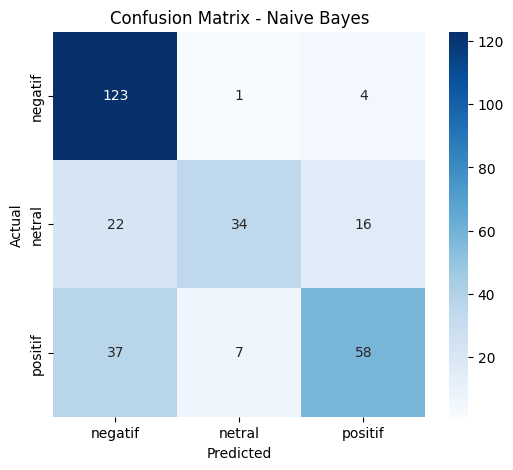

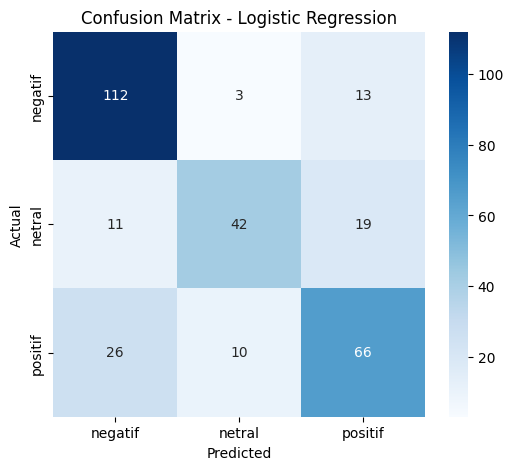

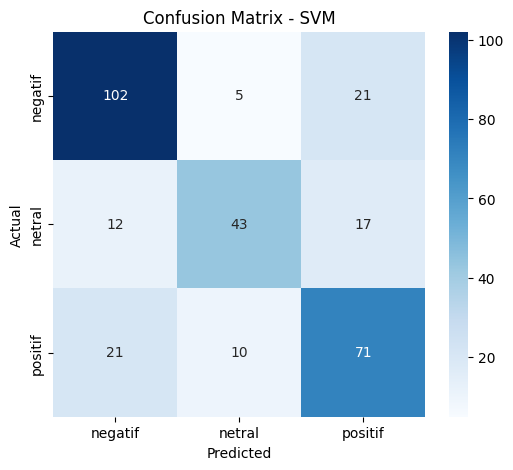

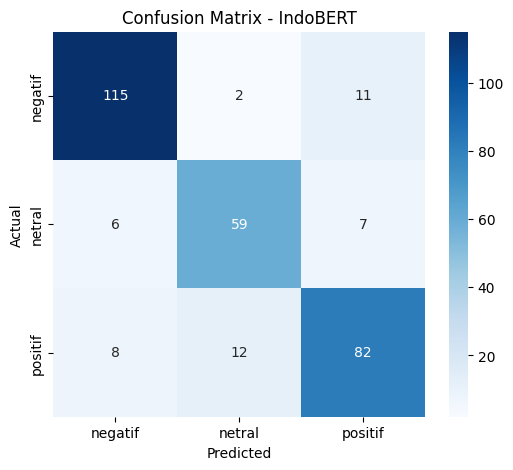

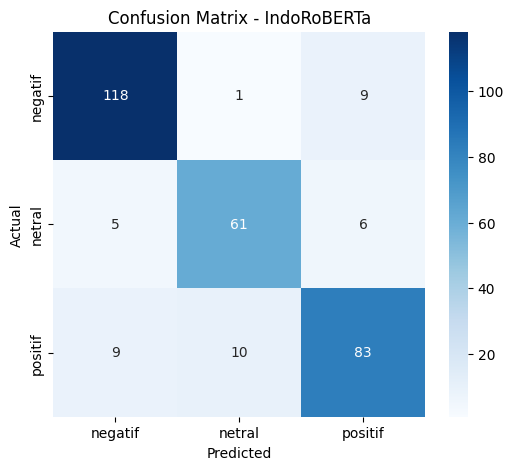

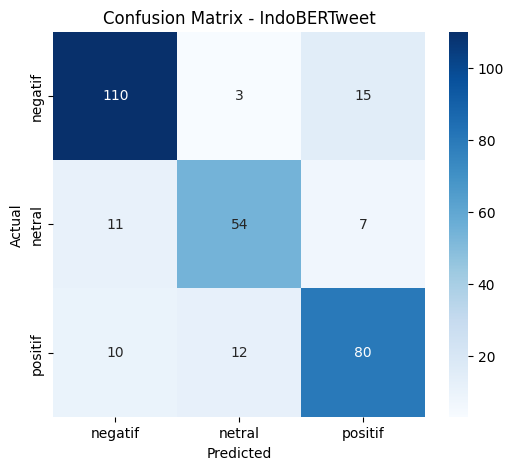

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, result in all_results.items():

    cm = confusion_matrix(
        result["y_true"],
        result["y_pred"]
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title(f"Confusion Matrix - {model_name}")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

comparison = []

for model_name, result in all_results.items():

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            result["y_true"],
            result["y_pred"],
            average="macro"
        )
    )

    accuracy = accuracy_score(
        result["y_true"],
        result["y_pred"]
    )

    comparison.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1
    })

comparison_df = pd.DataFrame(comparison)

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.7119,0.7430,0.6673,0.6782
1,Logistic Regression,0.7285,0.7296,0.7018,0.7100
2,SVM,0.7152,0.7161,0.6967,0.7034
3,IndoBERT,0.8477,0.8399,0.8406,0.8402
4,IndoRoBERTa,0.8675,0.8627,0.8609,0.8616
5,IndoBERTweet,0.8079,0.8022,0.7979,0.7999


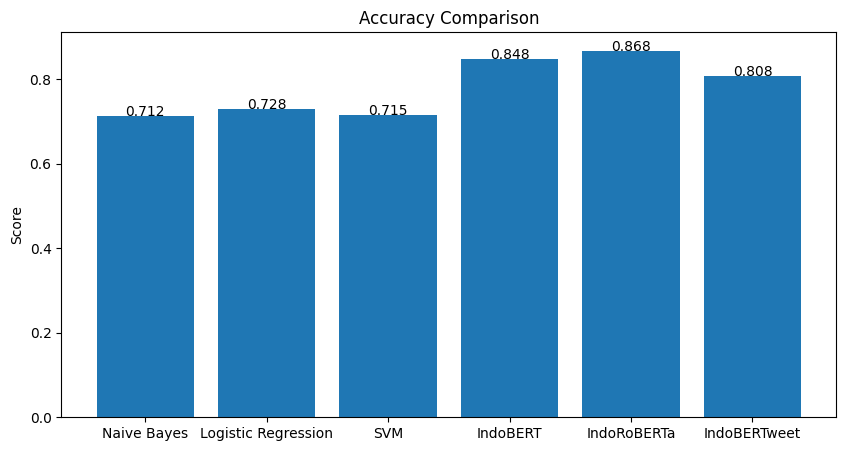

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center'
    )

plt.title("Accuracy Comparison")

plt.ylabel("Score")

plt.show()

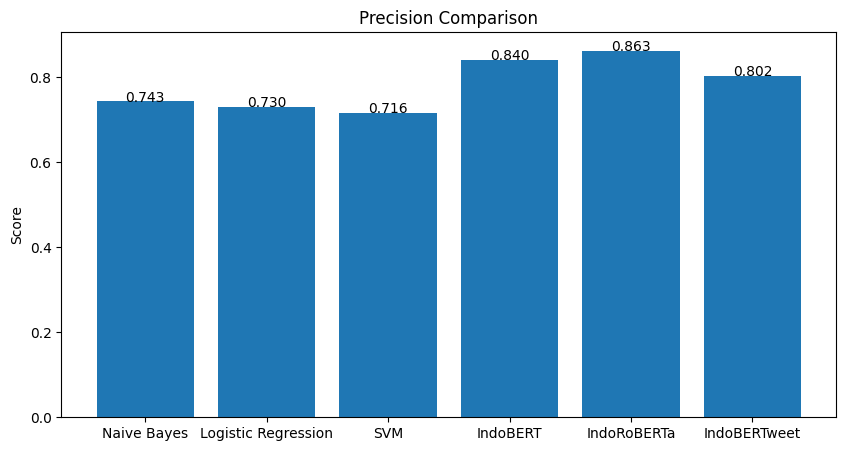

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Precision"]
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center'
    )

plt.title("Precision Comparison")

plt.ylabel("Score")

plt.show()

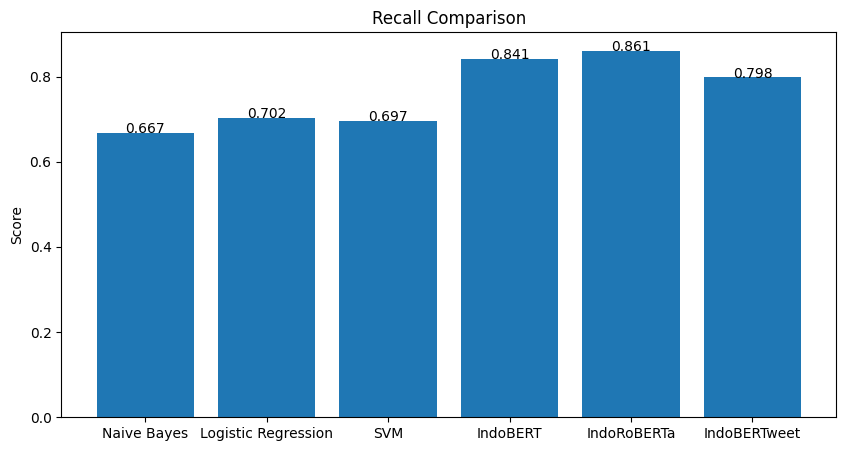

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Recall"]
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center'
    )

plt.title("Recall Comparison")

plt.ylabel("Score")

plt.show()

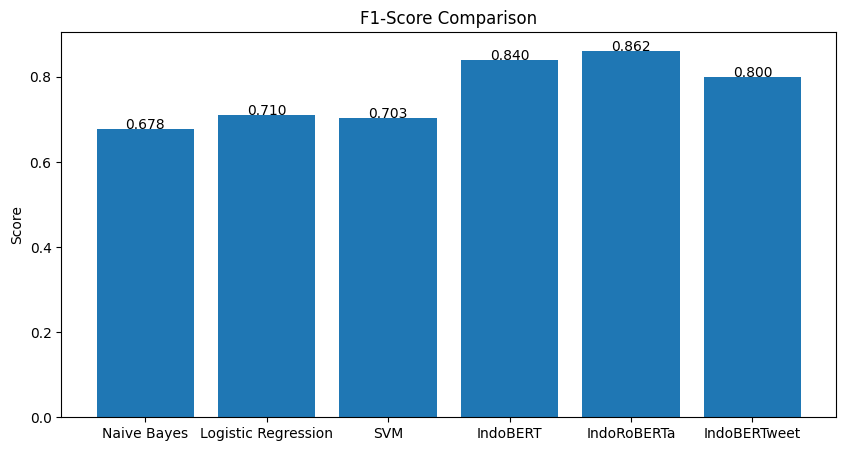

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["F1"]
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center'
    )

plt.title("F1-Score Comparison")

plt.ylabel("Score")

plt.show()

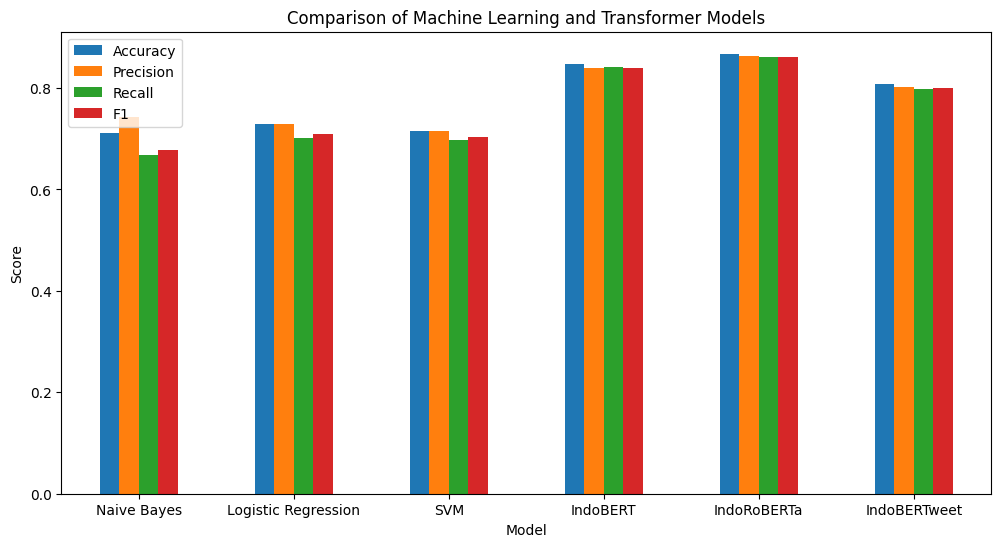

In [ ]:
comparison_df.set_index(
    "Model"
)[["Accuracy","Precision","Recall","F1"]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning and Transformer Models")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.legend(loc="best")

plt.show()

In [ ]:
comparison_df.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
4,IndoRoBERTa,0.867550,0.862700,0.860941,0.861638
3,IndoBERT,0.847682,0.839897,0.840601,0.840205
5,IndoBERTweet,0.807947,0.802206,0.797896,0.799897
1,Logistic Regression,0.728477,0.729595,0.701797,0.710027
2,SVM,0.715232,0.716104,0.696725,0.703397
0,Naive Bayes,0.711921,0.742979,0.667262,0.678161


# Sentiment Interpretation

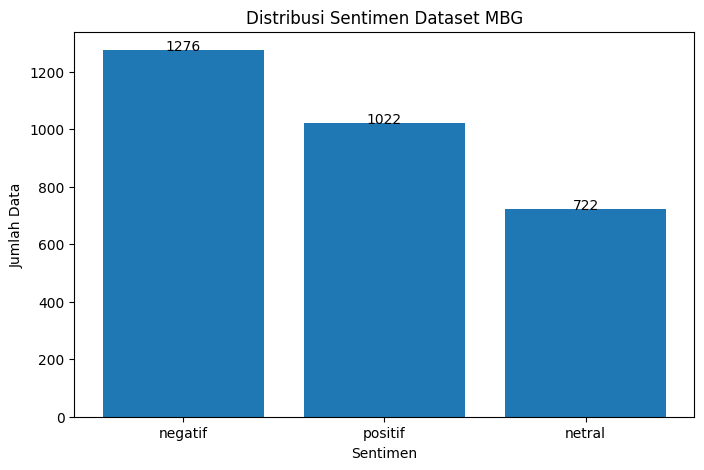

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = (
    final_df['final_label']
    .value_counts()
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center'
    )

plt.title(
    "Distribusi Sentimen Dataset MBG"
)

plt.xlabel("Sentimen")

plt.ylabel("Jumlah Data")

plt.show()

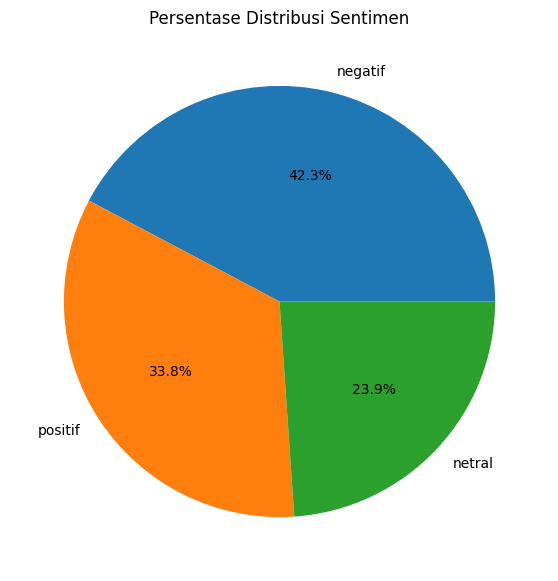

In [ ]:
plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title(
    "Persentase Distribusi Sentimen"
)

plt.show()

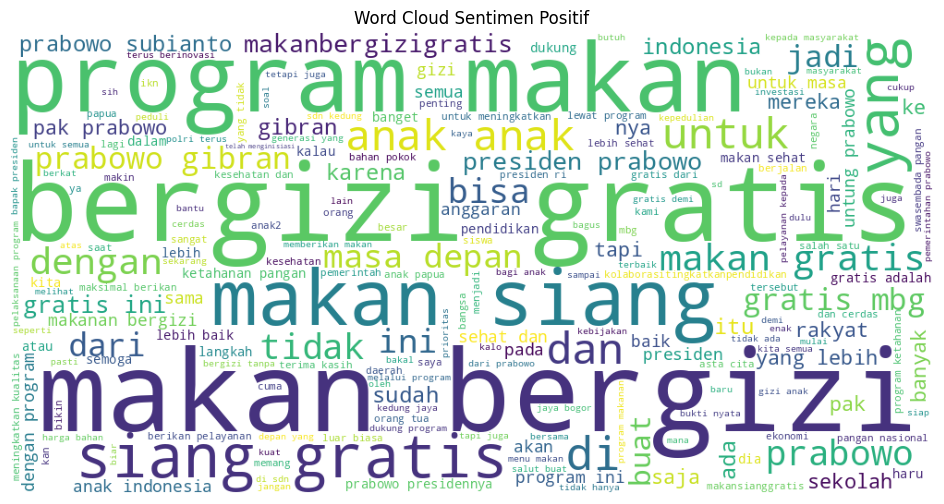

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(
    final_df[
        final_df['final_label'] == 'positif'
    ]['text_clean']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Word Cloud Sentimen Positif"
)

plt.show()

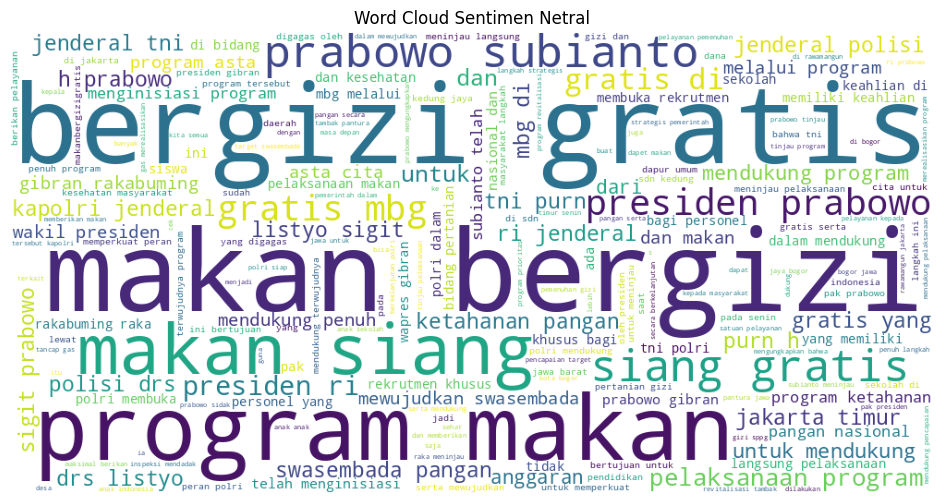

In [ ]:
neutral_text = " ".join(
    final_df[
        final_df['final_label'] == 'netral'
    ]['text_clean']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(neutral_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Word Cloud Sentimen Netral"
)

plt.show()

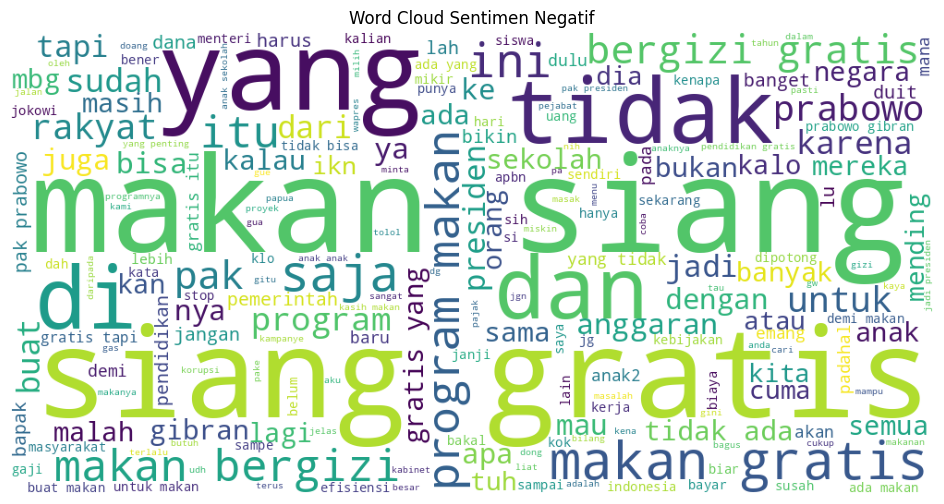

In [ ]:
negative_text = " ".join(
    final_df[
        final_df['final_label'] == 'negatif'
    ]['text_clean']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Word Cloud Sentimen Negatif"
)

plt.show()

In [ ]:
tfidf
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 67579 stored elements and shape (2416, 5000)>

In [ ]:
import pandas as pd
import numpy as np

feature_names = tfidf.get_feature_names_out()

scores = np.asarray(
    X_train_tfidf.sum(axis=0)
).flatten()

tfidf_df = pd.DataFrame({

    "term": feature_names,

    "score": scores
})

top_tfidf = (
    tfidf_df
    .sort_values(
        by="score",
        ascending=False
    )
    .head(20)
)

top_tfidf

,term,score
2455,makan,113.562533
1476,gratis,111.933239
4270,siang,91.353933
2488,makan siang,90.495141
3695,program,87.629897
4274,siang gratis,85.869849
556,bergizi,81.218330
4875,yang,77.170890
2462,makan bergizi,76.400169
3600,prabowo,75.934217


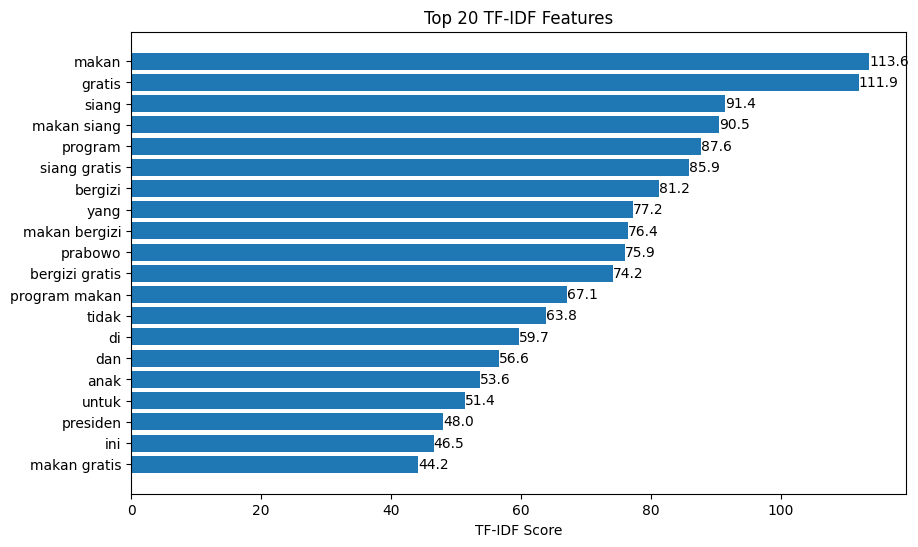

In [ ]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_tfidf['term'],
    top_tfidf['score']
)

for bar in bars:

    plt.text(
        bar.get_width(),
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va='center'
    )

plt.title(
    "Top 20 TF-IDF Features"
)

plt.xlabel("TF-IDF Score")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
positive_df = final_df[
    final_df['final_label']=="positif"
]

positive_tfidf = tfidf.fit_transform(
    positive_df['text_clean']
)

scores = np.asarray(
    positive_tfidf.sum(axis=0)
).flatten()

feature_names = tfidf.get_feature_names_out()

positive_keywords = pd.DataFrame({

    "term":feature_names,

    "score":scores
})

positive_keywords = (
    positive_keywords
    .sort_values(
        by="score",
        ascending=False
    )
    .head(15)
)

positive_keywords

,term,score
3320,makan,47.976870
2452,gratis,47.303179
402,bergizi,39.418974
4116,program,38.599318
3322,makan bergizi,36.994315
140,anak,36.769360
407,bergizi gratis,35.003788
4029,prabowo,34.902193
4462,siang,34.212576
3332,makan siang,33.845312


In [ ]:
positive_df = final_df[
    final_df['final_label']=="netral"
]

positive_tfidf = tfidf.fit_transform(
    positive_df['text_clean']
)

scores = np.asarray(
    positive_tfidf.sum(axis=0)
).flatten()

feature_names = tfidf.get_feature_names_out()

positive_keywords = pd.DataFrame({

    "term":feature_names,

    "score":scores
})

positive_keywords = (
    positive_keywords
    .sort_values(
        by="score",
        ascending=False
    )
    .head(15)
)

positive_keywords

,term,score
1563,gratis,32.719322
3332,makan,32.582004
4396,program,32.125025
4332,prabowo,28.354477
265,bergizi,27.950585
266,bergizi gratis,27.522052
3336,makan bergizi,27.438487
4401,program makan,23.824284
4617,siang,23.682329
806,di,23.476319


In [ ]:
positive_df = final_df[
    final_df['final_label']=="negatif"
]

positive_tfidf = tfidf.fit_transform(
    positive_df['text_clean']
)

scores = np.asarray(
    positive_tfidf.sum(axis=0)
).flatten()

feature_names = tfidf.get_feature_names_out()

positive_keywords = pd.DataFrame({

    "term":feature_names,

    "score":scores
})

positive_keywords = (
    positive_keywords
    .sort_values(
        by="score",
        ascending=False
    )
    .head(15)
)

positive_keywords

,term,score
2626,makan,58.983709
1485,gratis,57.525936
4218,siang,51.323867
2657,makan siang,51.058655
4222,siang gratis,48.910122
4852,yang,48.193666
4515,tidak,47.202941
3766,program,35.044696
1025,di,29.619435
2641,makan gratis,27.685922


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

positive_text = final_df[
    final_df['final_label'] == 'positif'
]['text_clean']

tfidf_pos = TfidfVectorizer(max_features=5000)

X_pos = tfidf_pos.fit_transform(
    positive_text
)

scores = np.asarray(
    X_pos.sum(axis=0)
).flatten()

terms = tfidf_pos.get_feature_names_out()

top_positive = pd.DataFrame({
    'Kata': terms,
    'Skor': scores
})

top_positive = (
    top_positive
    .sort_values(
        by='Skor',
        ascending=False
    )
    .head(3)
)

top_positive

,Kata,Skor
1862,makan,63.939497
1149,gratis,62.275454
419,bergizi,55.112123


In [ ]:
neutral_text = final_df[
    final_df['final_label'] == 'netral'
]['text_clean']

tfidf_neu = TfidfVectorizer(max_features=5000)

X_neu = tfidf_neu.fit_transform(
    neutral_text
)

scores = np.asarray(
    X_neu.sum(axis=0)
).flatten()

terms = tfidf_neu.get_feature_names_out()

top_neutral = pd.DataFrame({
    'Kata': terms,
    'Skor': scores
})

top_neutral = (
    top_neutral
    .sort_values(
        by='Skor',
        ascending=False
    )
    .head(3)
)

top_neutral

,Kata,Skor
1826,program,45.832727
718,gratis,45.158697
1196,makan,44.910892


In [ ]:
negative_text = final_df[
    final_df['final_label'] == 'negatif'
]['text_clean']

tfidf_neg = TfidfVectorizer(max_features=5000)

X_neg = tfidf_neg.fit_transform(
    negative_text
)

scores = np.asarray(
    X_neg.sum(axis=0)
).flatten()

terms = tfidf_neg.get_feature_names_out()

top_negative = pd.DataFrame({
    'Kata': terms,
    'Skor': scores
})

top_negative = (
    top_negative
    .sort_values(
        by='Skor',
        ascending=False
    )
    .head(3)
)

top_negative

,Kata,Skor
2664,makan,69.706359
1549,gratis,67.969419
4618,siang,60.604882


In [ ]:
hasil_top3 = pd.DataFrame({

    "Positif": top_positive["Kata"].values,

    "Netral": top_neutral["Kata"].values,

    "Negatif": top_negative["Kata"].values

})

hasil_top3

,Positif,Netral,Negatif
0,makan,program,makan
1,gratis,gratis,gratis
2,bergizi,makan,siang
